# Advanced Classification Model Training

This notebook implements advanced ML techniques to improve accuracy:
- RandomizedSearchCV for hyperparameter tuning
- Polynomial feature engineering
- Ensemble methods (Voting & Stacking)
- Additional models (SVM, Neural Network)

## 1. Imports and Setup

In [63]:
# Install into THIS notebook kernel (Python 3.14), not a different pip
%pip install shap


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, label_binarize  # NEW: label_binarize for OvR ROC
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               VotingClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    roc_curve, auc,  # NEW: ROC-AUC evaluation
)
from scipy.stats import randint, uniform
import joblib
import warnings
import time
import shap  # NEW: SHAP interpretability

warnings.filterwarnings('ignore')
np.random.seed(42)

print("="*80)
print("ADVANCED CLASSIFICATION MODEL TRAINING")
print("="*80)

ADVANCED CLASSIFICATION MODEL TRAINING


## 2. Load and Prepare Data

In [65]:
# Load data
print("\n1. Loading data...")
df = pd.read_csv('finalllama.csv')
print(f"   Dataset shape: {df.shape}")

# Feature engineering
print("\n2. Feature engineering...")
df = df[(df['dataset'] == 'glue/sst2') | (df['dataset'] == 'boolq')]
df_processed = df.copy()
features_to_drop = ['id', 'label','prompt_complexity_score','dataset']
X = df_processed.drop(features_to_drop, axis=1)
y = df_processed['label']
feature_names = list(X.columns)  # NEW: used later for SHAP feature labels
print(f"   Dataset shape changed: {df.shape}")
print(f"   Original features: {X.shape[1]}")


1. Loading data...
   Dataset shape: (17998, 12)

2. Feature engineering...
   Dataset shape changed: (3353, 12)
   Original features: 8


## 3. Train-Test Split and Scaling

In [66]:
# Train-test split
print("\n3. Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Test set: {X_test.shape[0]} samples")

# Scaling
print("\n4. Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Setup cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Results storage
all_results = []


3. Splitting data...
   Training set: 2682 samples
   Test set: 671 samples

4. Scaling features...


## 4. Baseline Models

In [67]:
print("\n" + "="*80)
print("BASELINE MODELS (from train_improved.py)")
print("="*80)

baseline_models = {
    'XGBoost_baseline': XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        random_state=42, eval_metric='logloss'
    ),
    'GradientBoosting_baseline': GradientBoostingClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
    ),
    'RandomForest_baseline': RandomForestClassifier(
        n_estimators=100, class_weight='balanced', max_depth=10,
        min_samples_split=10, min_samples_leaf=4, random_state=42
    )
}

for name, model in baseline_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    
    all_results.append({
        'Model': name,
        'Approach': 'Baseline',
        'Train_Acc': train_acc,
        'Test_Acc': test_acc,
        'F1_Macro': f1_macro,
        'Overfit_Gap': train_acc - test_acc
    })
    
    print(f"  Test Acc: {test_acc:.4f}, F1 Macro: {f1_macro:.4f}")


BASELINE MODELS (from train_improved.py)

Training XGBoost_baseline...
  Test Acc: 0.9061, F1 Macro: 0.8060

Training GradientBoosting_baseline...
  Test Acc: 0.9344, F1 Macro: 0.8758

Training RandomForest_baseline...
  Test Acc: 0.9404, F1 Macro: 0.9023


## 5. RandomizedSearchCV - XGBoost

In [68]:
print("\n" + "="*80)
print("RANDOMIZED SEARCH CV - HYPERPARAMETER TUNING")
print("="*80)

# XGBoost RandomizedSearch
print("\nTuning XGBoost with RandomizedSearchCV...")
xgb_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.19),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'min_child_weight': randint(1, 7),
    'gamma': uniform(0, 0.5)
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=xgb_param_dist,
    n_iter=50,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0,
    random_state=42
)

start_time = time.time()
xgb_random.fit(X_train_scaled, y_train)
print(f"  Time taken: {time.time() - start_time:.2f}s")
print(f"  Best params: {xgb_random.best_params_}")

best_xgb = xgb_random.best_estimator_
y_pred = best_xgb.predict(X_test_scaled)
train_acc = accuracy_score(y_train, best_xgb.predict(X_train_scaled))
test_acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

all_results.append({
    'Model': 'XGBoost_RandomSearch',
    'Approach': 'RandomizedSearchCV',
    'Train_Acc': train_acc,
    'Test_Acc': test_acc,
    'F1_Macro': f1_macro,
    'Overfit_Gap': train_acc - test_acc
})

print(f"  Test Acc: {test_acc:.4f}, F1 Macro: {f1_macro:.4f}")


RANDOMIZED SEARCH CV - HYPERPARAMETER TUNING

Tuning XGBoost with RandomizedSearchCV...
  Time taken: 4.45s
  Best params: {'colsample_bytree': 0.7799016533479063, 'gamma': 0.1975751180009072, 'learning_rate': 0.1860651845008209, 'max_depth': 9, 'min_child_weight': 6, 'n_estimators': 314, 'subsample': 0.8083337040103294}
  Test Acc: 0.9583, F1 Macro: 0.9280


## 6. RandomizedSearchCV - Random Forest

In [69]:
# Random Forest RandomizedSearch
print("\nTuning Random Forest with RandomizedSearchCV...")
rf_param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': randint(5, 20),
    'min_samples_split': randint(5, 25),
    'min_samples_leaf': randint(2, 10),
    'max_features': uniform(0.3, 0.7)
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_distributions=rf_param_dist,
    n_iter=50,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0,
    random_state=42
)

start_time = time.time()
rf_random.fit(X_train_scaled, y_train)
print(f"  Time taken: {time.time() - start_time:.2f}s")
print(f"  Best params: {rf_random.best_params_}")

best_rf = rf_random.best_estimator_
y_pred = best_rf.predict(X_test_scaled)
train_acc = accuracy_score(y_train, best_rf.predict(X_train_scaled))
test_acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

all_results.append({
    'Model': 'RandomForest_RandomSearch',
    'Approach': 'RandomizedSearchCV',
    'Train_Acc': train_acc,
    'Test_Acc': test_acc,
    'F1_Macro': f1_macro,
    'Overfit_Gap': train_acc - test_acc
})

print(f"  Test Acc: {test_acc:.4f}, F1 Macro: {f1_macro:.4f}")


Tuning Random Forest with RandomizedSearchCV...
  Time taken: 23.67s
  Best params: {'max_depth': 19, 'max_features': 0.42135525745544045, 'min_samples_leaf': 2, 'min_samples_split': 8, 'n_estimators': 149}
  Test Acc: 0.9583, F1 Macro: 0.9308


## 7. Polynomial Features

In [70]:
print("\n" + "="*80)
print("POLYNOMIAL FEATURES")
print("="*80)

print("\nGenerating polynomial features (degree=2)...")
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print(f"  Features expanded: {X_train_scaled.shape[1]} -> {X_train_poly.shape[1]}")

# Test XGBoost with polynomial features
print("\nTraining XGBoost with polynomial features...")
xgb_poly = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    random_state=42, eval_metric='logloss'
)
xgb_poly.fit(X_train_poly, y_train)

y_pred = xgb_poly.predict(X_test_poly)
train_acc = accuracy_score(y_train, xgb_poly.predict(X_train_poly))
test_acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

all_results.append({
    'Model': 'XGBoost_Polynomial',
    'Approach': 'Polynomial Features',
    'Train_Acc': train_acc,
    'Test_Acc': test_acc,
    'F1_Macro': f1_macro,
    'Overfit_Gap': train_acc - test_acc
})

print(f"  Test Acc: {test_acc:.4f}, F1 Macro: {f1_macro:.4f}")


POLYNOMIAL FEATURES

Generating polynomial features (degree=2)...
  Features expanded: 8 -> 44

Training XGBoost with polynomial features...
  Test Acc: 0.9657, F1 Macro: 0.9418


## 8. Feature Selection on Polynomial Features

In [71]:
# Feature selection on polynomial features
print("\nApplying feature selection (SelectKBest, k=20)...")
selector = SelectKBest(f_classif, k=20)
X_train_selected = selector.fit_transform(X_train_poly, y_train)
X_test_selected = selector.transform(X_test_poly)

print(f"  Features after selection: {X_train_selected.shape[1]}")

xgb_selected = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    random_state=42, eval_metric='logloss'
)
xgb_selected.fit(X_train_selected, y_train)

y_pred = xgb_selected.predict(X_test_selected)
train_acc = accuracy_score(y_train, xgb_selected.predict(X_train_selected))
test_acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

all_results.append({
    'Model': 'XGBoost_PolySelected',
    'Approach': 'Poly + SelectKBest',
    'Train_Acc': train_acc,
    'Test_Acc': test_acc,
    'F1_Macro': f1_macro,
    'Overfit_Gap': train_acc - test_acc
})

print(f"  Test Acc: {test_acc:.4f}, F1 Macro: {f1_macro:.4f}")


Applying feature selection (SelectKBest, k=20)...
  Features after selection: 20
  Test Acc: 0.9627, F1 Macro: 0.9355


## 9. Additional Models - SVM

In [72]:
print("\n" + "="*80)
print("ADDITIONAL MODELS")
print("="*80)

# SVM
print("\nTraining SVM...")
start_time = time.time()
svm_clf = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    C=10,
    gamma='scale',
    random_state=42
)
svm_clf.fit(X_train_scaled, y_train)
print(f"  Time taken: {time.time() - start_time:.2f}s")

y_pred = svm_clf.predict(X_test_scaled)
train_acc = accuracy_score(y_train, svm_clf.predict(X_train_scaled))
test_acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

all_results.append({
    'Model': 'SVM',
    'Approach': 'New Model',
    'Train_Acc': train_acc,
    'Test_Acc': test_acc,
    'F1_Macro': f1_macro,
    'Overfit_Gap': train_acc - test_acc
})

print(f"  Test Acc: {test_acc:.4f}, F1 Macro: {f1_macro:.4f}")


ADDITIONAL MODELS

Training SVM...
  Time taken: 0.46s
  Test Acc: 0.7407, F1 Macro: 0.6650


## 10. Additional Models - Neural Network

In [73]:
# Neural Network
print("\nTraining Neural Network (MLP)...")
start_time = time.time()
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.2,
    random_state=42
)
mlp_clf.fit(X_train_scaled, y_train)
print(f"  Time taken: {time.time() - start_time:.2f}s")

y_pred = mlp_clf.predict(X_test_scaled)
train_acc = accuracy_score(y_train, mlp_clf.predict(X_train_scaled))
test_acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

all_results.append({
    'Model': 'NeuralNetwork',
    'Approach': 'New Model',
    'Train_Acc': train_acc,
    'Test_Acc': test_acc,
    'F1_Macro': f1_macro,
    'Overfit_Gap': train_acc - test_acc
})

print(f"  Test Acc: {test_acc:.4f}, F1 Macro: {f1_macro:.4f}")


Training Neural Network (MLP)...
  Time taken: 0.08s
  Test Acc: 0.8271, F1 Macro: 0.5375


## 11. Ensemble Methods - Voting Classifier

In [74]:
print("\n" + "="*80)
print("ENSEMBLE METHODS")
print("="*80)

# VotingClassifier
print("\nTraining VotingClassifier (Soft Voting)...")
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('rf', best_rf),
        ('gb', GradientBoostingClassifier(
            n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
        ))
    ],
    voting='soft',
    weights=[2, 1, 1]
)

start_time = time.time()
voting_clf.fit(X_train_scaled, y_train)
print(f"  Time taken: {time.time() - start_time:.2f}s")

y_pred = voting_clf.predict(X_test_scaled)
train_acc = accuracy_score(y_train, voting_clf.predict(X_train_scaled))
test_acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

all_results.append({
    'Model': 'VotingClassifier',
    'Approach': 'Ensemble',
    'Train_Acc': train_acc,
    'Test_Acc': test_acc,
    'F1_Macro': f1_macro,
    'Overfit_Gap': train_acc - test_acc
})

print(f"  Test Acc: {test_acc:.4f}, F1 Macro: {f1_macro:.4f}")


ENSEMBLE METHODS

Training VotingClassifier (Soft Voting)...
  Time taken: 1.26s
  Test Acc: 0.9598, F1 Macro: 0.9299


## 12. Ensemble Methods - Stacking Classifier

In [75]:
# StackingClassifier
print("\nTraining StackingClassifier...")
stacking_clf = StackingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('rf', best_rf),
        ('gb', GradientBoostingClassifier(
            n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
        )),
        ('lr', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
    ],
    final_estimator=XGBClassifier(max_depth=3, random_state=42, eval_metric='logloss'),
    cv=5
)

start_time = time.time()
stacking_clf.fit(X_train_scaled, y_train)
print(f"  Time taken: {time.time() - start_time:.2f}s")

y_pred = stacking_clf.predict(X_test_scaled)
train_acc = accuracy_score(y_train, stacking_clf.predict(X_train_scaled))
test_acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')

all_results.append({
    'Model': 'StackingClassifier',
    'Approach': 'Ensemble',
    'Train_Acc': train_acc,
    'Test_Acc': test_acc,
    'F1_Macro': f1_macro,
    'Overfit_Gap': train_acc - test_acc
})

print(f"  Test Acc: {test_acc:.4f}, F1 Macro: {f1_macro:.4f}")


Training StackingClassifier...
  Time taken: 6.92s
  Test Acc: 0.9598, F1 Macro: 0.9317


## 13. Results Summary

In [76]:
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)

results_df = pd.DataFrame(all_results).sort_values('Test_Acc', ascending=False)
print(results_df.to_string(index=False))

# Save results
results_df.to_csv('advanced_results.csv', index=False)
print("\n✅ Results saved to 'advanced_results.csv'")

# Get best model
best_row = results_df.iloc[0]
print(f"\n{'='*80}")
print(f"BEST MODEL: {best_row['Model']}")
print(f"{'='*80}")
print(f"Approach: {best_row['Approach']}")
print(f"Test Accuracy: {best_row['Test_Acc']:.4f}")
print(f"F1 Macro: {best_row['F1_Macro']:.4f}")
print(f"Overfitting Gap: {best_row['Overfit_Gap']:.4f}")


RESULTS SUMMARY
                    Model            Approach  Train_Acc  Test_Acc  F1_Macro  Overfit_Gap
       XGBoost_Polynomial Polynomial Features   0.985086  0.965723  0.941837     0.019363
     XGBoost_PolySelected  Poly + SelectKBest   0.979866  0.962742  0.935517     0.017124
         VotingClassifier            Ensemble   0.981730  0.959762  0.929887     0.021969
       StackingClassifier            Ensemble   0.973527  0.959762  0.931722     0.013766
     XGBoost_RandomSearch  RandomizedSearchCV   0.981357  0.958271  0.928020     0.023086
RandomForest_RandomSearch  RandomizedSearchCV   0.981730  0.958271  0.930751     0.023459
    RandomForest_baseline            Baseline   0.966443  0.940387  0.902286     0.026055
GradientBoosting_baseline            Baseline   0.958986  0.934426  0.875803     0.024560
         XGBoost_baseline            Baseline   0.946309  0.906110  0.806013     0.040198
            NeuralNetwork           New Model   0.828859  0.827124  0.537461     0.

## 14. Detailed Evaluation of Best Model

In [77]:
print(f"\n{'='*80}")
print(f"DETAILED EVALUATION - {best_row['Model']}")
print(f"{'='*80}")

# Determine which model object to use
if 'RandomSearch' in best_row['Model'] and 'XGBoost' in best_row['Model']:
    best_model_obj = best_xgb
    X_test_final = X_test_scaled
elif 'RandomSearch' in best_row['Model'] and 'RandomForest' in best_row['Model']:
    best_model_obj = best_rf
    X_test_final = X_test_scaled
elif 'Polynomial' in best_row['Model'] and 'Selected' not in best_row['Model']:
    best_model_obj = xgb_poly
    X_test_final = X_test_poly
elif 'PolySelected' in best_row['Model']:
    best_model_obj = xgb_selected
    X_test_final = X_test_selected
elif best_row['Model'] == 'SVM':
    best_model_obj = svm_clf
    X_test_final = X_test_scaled
elif best_row['Model'] == 'NeuralNetwork':
    best_model_obj = mlp_clf
    X_test_final = X_test_scaled
elif best_row['Model'] == 'VotingClassifier':
    best_model_obj = voting_clf
    X_test_final = X_test_scaled
elif best_row['Model'] == 'StackingClassifier':
    best_model_obj = stacking_clf
    X_test_final = X_test_scaled
else:
    # Baseline models
    best_model_obj = list(baseline_models.values())[0]
    X_test_final = X_test_scaled

y_pred_final = best_model_obj.predict(X_test_final)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=['Class 0', 'Class 1']))


DETAILED EVALUATION - XGBoost_Polynomial

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.92      0.89      0.90       122
     Class 1       0.98      0.98      0.98       549

    accuracy                           0.97       671
   macro avg       0.95      0.94      0.94       671
weighted avg       0.97      0.97      0.97       671



## 15. Visualizations

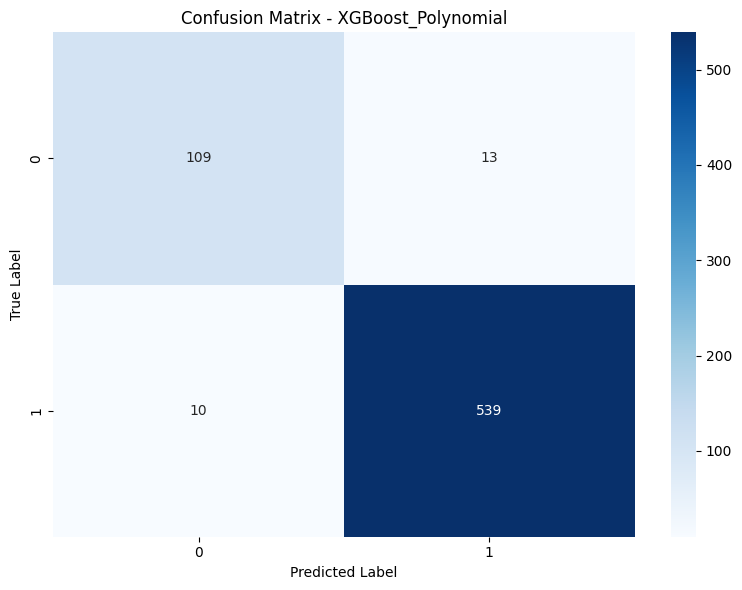

✅ Confusion matrix saved as 'advanced_confusion_matrix.png'


In [78]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'Confusion Matrix - {best_row["Model"]}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('advanced_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved as 'advanced_confusion_matrix.png'")

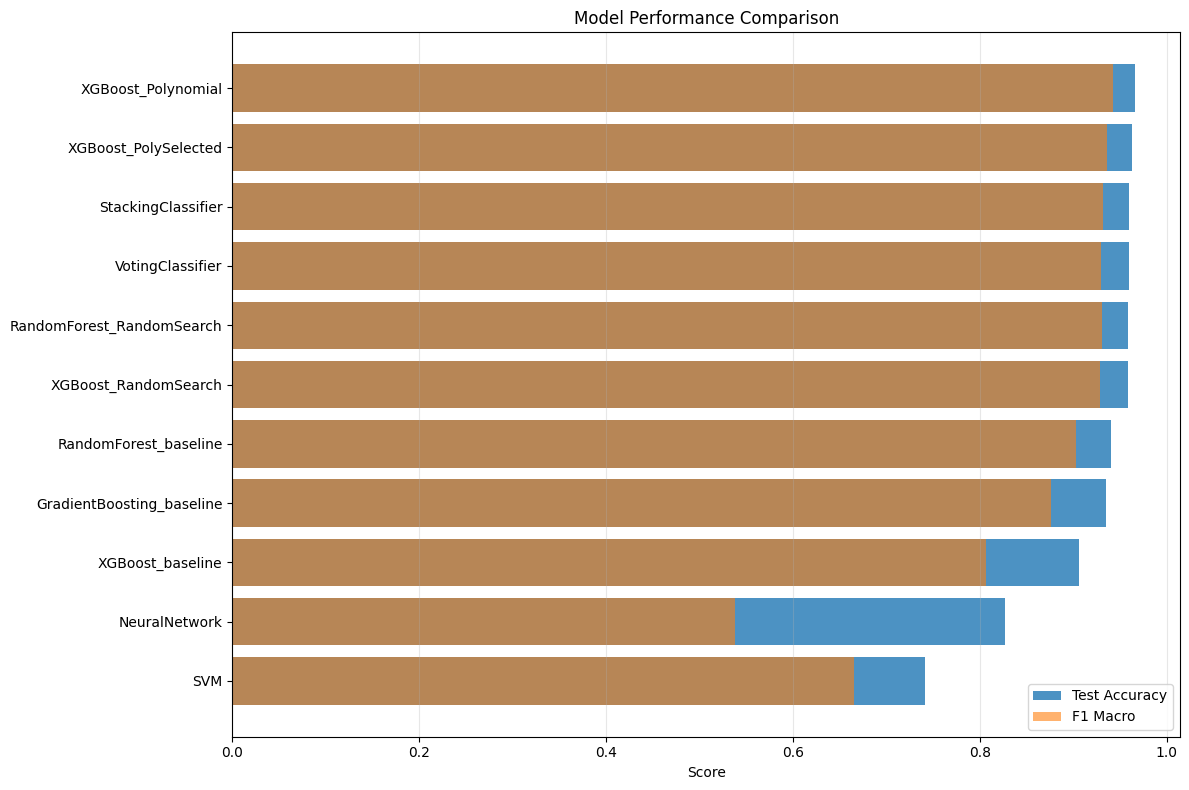

✅ Comparison plot saved as 'advanced_comparison.png'


In [79]:
# Comparison plot
plt.figure(figsize=(12, 8))
results_plot = results_df.sort_values('Test_Acc')
y_pos = np.arange(len(results_plot))

plt.barh(y_pos, results_plot['Test_Acc'], alpha=0.8, label='Test Accuracy')
plt.barh(y_pos, results_plot['F1_Macro'], alpha=0.6, label='F1 Macro')

plt.yticks(y_pos, results_plot['Model'])
plt.xlabel('Score')
plt.title('Model Performance Comparison')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('advanced_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison plot saved as 'advanced_comparison.png'")

## 15b. SHAP Interpretability and ROC-AUC (`voting_clf`)

**Inserted section** (existing training/evaluation pipeline unchanged). Uses the best model `voting_clf`, scaled train/test features, `y_test`, and `feature_names`. SHAP uses a model-agnostic explainer (not TreeExplainer). ROC is computed from `voting_clf.predict_proba`.

Computing model-agnostic SHAP for VotingClassifier (may take a few minutes)...


ExactExplainer explainer: 672it [00:38, 12.84it/s]                         


SHAP method: Exact (model-agnostic)
=== SHAP Feature Importance ===
compressed_prompt_len: 0.053940
task_type_prob: 0.051046
reasoning: 0.041205
domain_knowledge: 0.035468
creativity_scope: 0.035304
contextual_knowledge: 0.033916
constraint_ct: 0.026577
number_of_few_shots: 0.021763


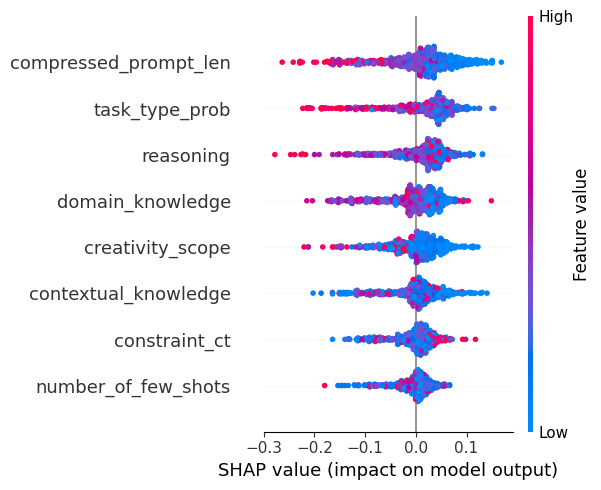

Saved shap_summary.png


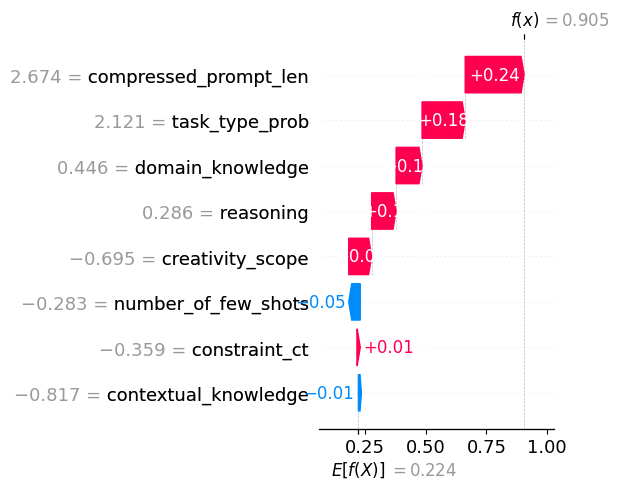

Saved shap_local.png (test index 0, true=0, pred=0)

=== ROC-AUC Results ===
Class 0: 0.9774
Class 1: 0.9774
Macro AUC: 0.9774


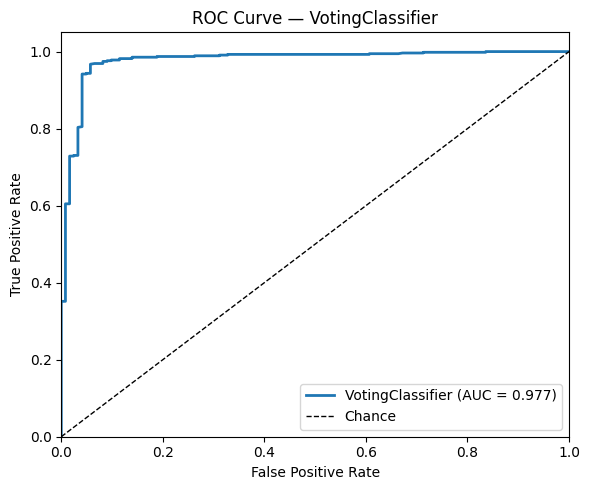

Saved roc_curve.png


In [80]:
# =============================================================================
# NEW SECTION (inserted): SHAP (model-agnostic) + ROC-AUC for voting_clf
# Existing pipeline above is unchanged.
# =============================================================================

X_shap = np.asarray(X_test_scaled, dtype=float)
y_true = np.asarray(y_test)
n_features = len(feature_names)

# Small background sample from the training distribution (Kernel/Exact SHAP)
n_bg = int(min(50, len(X_train_scaled)))
X_bg = shap.sample(np.asarray(X_train_scaled, dtype=float), n_bg, random_state=42)


def voting_predict_proba(X):
    """Model-agnostic prediction function for the VotingClassifier."""
    return voting_clf.predict_proba(np.asarray(X, dtype=float))


print("Computing model-agnostic SHAP for VotingClassifier (may take a few minutes)...")

shap_explanation = None
expected_raw = None
shap_values_raw = None

# Prefer Exact SHAP (feasible with few features), then shap.Explainer, then KernelExplainer
try:
    masker = shap.maskers.Independent(X_bg)
    explainer = shap.explainers.Exact(voting_predict_proba, masker)
    shap_explanation = explainer(X_shap)
    shap_values_raw = shap_explanation.values
    expected_raw = shap_explanation.base_values
    print("SHAP method: Exact (model-agnostic)")
except Exception as e_exact:
    print(f"Exact explainer unavailable ({type(e_exact).__name__}: {e_exact}). Trying shap.Explainer...")
    try:
        explainer = shap.Explainer(voting_predict_proba, X_bg, feature_names=list(feature_names))
        shap_explanation = explainer(X_shap)
        shap_values_raw = shap_explanation.values
        expected_raw = shap_explanation.base_values
        print("SHAP method: shap.Explainer (model-agnostic)")
    except Exception as e_exp:
        print(f"shap.Explainer unavailable ({type(e_exp).__name__}: {e_exp}). Falling back to KernelExplainer...")
        explainer = shap.KernelExplainer(voting_predict_proba, X_bg)
        shap_values_raw = explainer.shap_values(X_shap, nsamples=100)
        expected_raw = explainer.expected_value
        print("SHAP method: KernelExplainer (model-agnostic)")

if isinstance(shap_values_raw, list):
    shap_arr = np.stack([np.asarray(sv) for sv in shap_values_raw], axis=-1)
else:
    shap_arr = np.asarray(shap_values_raw)

# predict_proba SHAP is typically (n, features, n_classes)
if shap_arr.ndim == 3 and shap_arr.shape[-1] == 2:
    shap_for_summary = shap_arr[:, :, 1]  # positive class for binary beeswarm
elif shap_arr.ndim == 3:
    shap_for_summary = [shap_arr[:, :, k] for k in range(shap_arr.shape[-1])]
else:
    shap_for_summary = shap_arr

if shap_arr.ndim == 3:
    mean_abs_shap = np.abs(shap_arr).mean(axis=(0, 2))
else:
    mean_abs_shap = np.abs(shap_arr).mean(axis=0)

importance = sorted(zip(feature_names, mean_abs_shap), key=lambda x: x[1], reverse=True)

print("=== SHAP Feature Importance ===")
for name, val in importance:
    print(f"{name}: {val:.6f}")

shap.summary_plot(
    shap_for_summary,
    X_shap,
    feature_names=feature_names,
    max_display=n_features,
    show=False,
)
plt.gcf().set_size_inches(6, 5)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved shap_summary.png")

# Local waterfall: first correctly classified test sample (else first sample)
y_pred_vote = voting_clf.predict(X_shap)
correct_idx = np.where(y_pred_vote == y_true)[0]
sample_idx = int(correct_idx[0]) if len(correct_idx) else 0
pred_label = y_pred_vote[sample_idx]
class_list = list(voting_clf.classes_)
class_index = class_list.index(pred_label)

if shap_arr.ndim == 3:
    sv_row = shap_arr[sample_idx, :, class_index]
else:
    sv_row = shap_arr[sample_idx]

ev = np.atleast_1d(np.asarray(expected_raw, dtype=float).reshape(-1))
if shap_arr.ndim == 3 and expected_raw is not None:
    ev_sample = np.asarray(expected_raw)
    if ev_sample.ndim == 2:
        base_value = float(ev_sample[sample_idx, min(class_index, ev_sample.shape[1] - 1)])
    elif ev_sample.ndim == 1 and ev_sample.size > class_index:
        base_value = float(ev_sample[class_index])
    else:
        base_value = float(ev.ravel()[-1] if shap_arr.shape[-1] == 2 else ev.ravel()[0])
elif len(ev) == 2:
    base_value = float(ev[1])
else:
    base_value = float(ev[0])

try:
    local_exp = shap.Explanation(
        values=sv_row,
        base_values=base_value,
        data=X_shap[sample_idx],
        feature_names=feature_names,
    )
    shap.plots.waterfall(local_exp, show=False)
except Exception:
    try:
        shap.waterfall_plot(base_value, sv_row, X_shap[sample_idx], feature_names=feature_names, show=False)
    except Exception:
        shap.waterfall_plot(base_value, sv_row, X_shap[sample_idx], feature_names=feature_names)

plt.gcf().set_size_inches(6, 5)
plt.tight_layout()
plt.savefig("shap_local.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved shap_local.png (test index {sample_idx}, true={y_true[sample_idx]}, pred={pred_label})")

# =============================================================================
# NEW SECTION (inserted): ROC-AUC for VotingClassifier (binary vs OvR multiclass)
# =============================================================================
y_proba = voting_clf.predict_proba(X_shap)
model_classes = np.asarray(voting_clf.classes_)
n_classes = len(model_classes)

y_bin = label_binarize(y_true, classes=model_classes)
if n_classes == 2 and y_bin.shape[1] == 1:
    y_bin = np.hstack([1 - y_bin, y_bin])

fpr_list, tpr_list, auc_list = [], [], []
for i, cls in enumerate(model_classes):
    fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], y_proba[:, i])
    auc_i = auc(fpr_i, tpr_i)
    fpr_list.append(fpr_i)
    tpr_list.append(tpr_i)
    auc_list.append(auc_i)

macro_auc = float(np.mean(auc_list))

print("\n=== ROC-AUC Results ===")
for cls, auc_i in zip(model_classes, auc_list):
    print(f"Class {cls}: {auc_i:.4f}")
print(f"Macro AUC: {macro_auc:.4f}")

if n_classes == 2:
    pos = 1 if y_proba.shape[1] > 1 else 0
    fpr, tpr, _ = roc_curve(y_true, y_proba[:, pos], pos_label=model_classes[pos])
    bin_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, lw=2, label=f"VotingClassifier (AUC = {bin_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve — VotingClassifier")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved roc_curve.png")
else:
    plt.figure(figsize=(6, 5))
    for i, cls in enumerate(model_classes):
        plt.plot(fpr_list[i], tpr_list[i], lw=2, label=f"Class {cls} (AUC = {auc_list[i]:.3f})")
    plt.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("One-vs-Rest ROC — VotingClassifier")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig("roc_curve_multiclass.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved roc_curve_multiclass.png")


## 16. Save Best Model

In [81]:
# Save best model as a Pipeline so inference always starts from the 8 raw features.
# XGBoost_PolySelected needs scaler -> poly -> SelectKBest -> clf.
name = str(best_row["Model"])
if "PolySelected" in name:
    best_pipeline = Pipeline([
        ("scaler", scaler),
        ("poly", poly),
        ("selector", selector),
        ("clf", xgb_selected),
    ])
elif "Polynomial" in name and "Selected" not in name:
    best_pipeline = Pipeline([
        ("scaler", scaler),
        ("poly", poly),
        ("clf", xgb_poly),
    ])
else:
    best_pipeline = Pipeline([
        ("scaler", scaler),
        ("clf", best_model_obj),
    ])

joblib.dump(best_pipeline, "best_advanced_model.pkl")
joblib.dump(scaler, "advanced_scaler.pkl")
print(f"Saved pipeline for {name}: {[step[0] for step in best_pipeline.steps]}")
print(f"Pipeline n_features_in_ (raw inputs): {best_pipeline.n_features_in_}")
print("✅ Scaler saved as 'advanced_scaler.pkl'")
print("✅ Best model pipeline saved as 'best_advanced_model.pkl'")

print(f"\n{'='*80}")
print("TRAINING COMPLETE!")
print(f"{'='*80}")

Saved pipeline for XGBoost_Polynomial: ['scaler', 'poly', 'clf']
Pipeline n_features_in_ (raw inputs): 8
✅ Scaler saved as 'advanced_scaler.pkl'
✅ Best model pipeline saved as 'best_advanced_model.pkl'

TRAINING COMPLETE!


In [82]:
def evaluate_with_threshold(model, X, y, threshold=0.5, positive_class=1):
    """
    Evaluate a model using a custom probability threshold.
    Note: This is mostly useful for binary classification or when focusing on a specific class.
    
    Args:
        model: The trained model (must have predict_proba method)
        X: Features to predict on
        y: True labels
        threshold: The probability threshold for predicting the positive class
        positive_class: The index of the class to treat as 'positive'
    """
    from sklearn.metrics import accuracy_score, classification_report
    import numpy as np
    
    if not hasattr(model, 'predict_proba'):
        print("Model does not support predict_proba.")
        return
        
    # Get probabilities for all classes
    probs = model.predict_proba(X)
    
    if probs.shape[1] > 2:
        print(f"Warning: Dataset has {probs.shape[1]} classes. Thresholding focuses on class {positive_class}.")
        # For multi-class, we predict positive_class if its prob > threshold, else we predict the argmax of the rest
        y_pred = np.argmax(probs, axis=1)
        positive_probs = probs[:, positive_class]
        y_pred[positive_probs >= threshold] = positive_class
        # For ones where prob < threshold but argmax was positive_class, assign to next best class
        mask = (positive_probs < threshold) & (np.argmax(probs, axis=1) == positive_class)
        if np.any(mask):
            temp_probs = probs.copy()
            temp_probs[:, positive_class] = -1 # remove positive class option
            y_pred[mask] = np.argmax(temp_probs[mask], axis=1)
    else:
        # Binary classification
        y_pred = (probs[:, positive_class] >= threshold).astype(int)
        
    acc = accuracy_score(y, y_pred)
    print(f"--- Threshold: {threshold} (Focus on Class {positive_class}) ---")
    print(f"Accuracy : {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y, y_pred))
    
    return y_pred, acc

# Example usage (uncomment to run with your best model):
new_preds, new_acc = evaluate_with_threshold(best_model_obj, X_test_final, y_test, threshold=0.53, positive_class=1)


--- Threshold: 0.53 (Focus on Class 1) ---
Accuracy : 0.9657

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       122
           1       0.98      0.98      0.98       549

    accuracy                           0.97       671
   macro avg       0.95      0.94      0.94       671
weighted avg       0.97      0.97      0.97       671



In [83]:
def evaluate_with_threshold(model, X, y, threshold=0.5, positive_class=1):
    from sklearn.metrics import accuracy_score, f1_score
    import numpy as np
    
    if not hasattr(model, 'predict_proba'):
        return None, None
        
    probs = model.predict_proba(X)
    y_pred = (probs[:, positive_class] >= threshold).astype(int)
    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred, average='macro')
    return acc, f1

def find_best_threshold(model, X, y, positive_class=1):
    import numpy as np
    
    # We will test thresholds from 0.1 to 0.9 in increments of 0.05
    thresholds = np.arange(0.1, 0.95, 0.05)
    best_acc = 0
    best_thresh_acc = 0
    best_f1 = 0
    best_thresh_f1 = 0
    
    print("Evaluating Thresholds...")
    for t in thresholds:
        acc, f1 = evaluate_with_threshold(model, X, y, threshold=t, positive_class=positive_class)
        if acc is None:
            print("Model doesn't support predict_proba")
            return
        
        if acc > best_acc:
            best_acc = acc
            best_thresh_acc = t
            
        if f1 > best_f1:
            best_f1 = f1
            best_thresh_f1 = t
            
    print(f"Best Threshold by Accuracy: {best_thresh_acc:.2f} (Acc: {best_acc:.4f})")
    print(f"Best Threshold by F1-Macro: {best_thresh_f1:.2f} (F1: {best_f1:.4f})")

    return best_thresh_acc, best_thresh_f1

# Run it on your best model
best_t_acc, best_t_f1 = find_best_threshold(best_model_obj, X_test_final, y_test, positive_class=1)


Evaluating Thresholds...
Best Threshold by Accuracy: 0.65 (Acc: 0.9702)
Best Threshold by F1-Macro: 0.65 (F1: 0.9505)


In [84]:
# Re-save the notebook winner (same logic as the Save Best Model cell).
# Do not dump voting_clf here — current winner is XGBoost_PolySelected (20 poly features).
name = str(best_row["Model"])
if "PolySelected" in name:
    best_pipeline = Pipeline([
        ("scaler", scaler),
        ("poly", poly),
        ("selector", selector),
        ("clf", xgb_selected),
    ])
elif "Polynomial" in name and "Selected" not in name:
    best_pipeline = Pipeline([
        ("scaler", scaler),
        ("poly", poly),
        ("clf", xgb_poly),
    ])
else:
    best_pipeline = Pipeline([
        ("scaler", scaler),
        ("clf", best_model_obj),
    ])

joblib.dump(best_pipeline, "best_advanced_model.pkl")
joblib.dump(scaler, "advanced_scaler.pkl")
print(type(best_pipeline.named_steps["clf"]), best_pipeline.n_features_in_)
print("steps:", list(best_pipeline.named_steps))

<class 'xgboost.sklearn.XGBClassifier'> 8
steps: ['scaler', 'poly', 'clf']


In [85]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(voting_clf, X_scaled, y, cv=5, scoring='f1_macro')
print(f"CV F1-Macro: {scores.mean():.4f} ± {scores.std():.4f}")


NameError: name 'X_scaled' is not defined

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Combine train + test back into full dataset
import numpy as np
X_all = np.vstack([X_train_scaled, X_test_scaled])
y_all = np.concatenate([y_train, y_test])

scores = cross_val_score(voting_clf, X_all, y_all, cv=5, scoring='f1_macro')
print(f"CV F1-Macro: {scores.mean():.4f} ± {scores.std():.4f}")

scores_acc = cross_val_score(voting_clf, X_all, y_all, cv=5, scoring='accuracy')
print(f"CV Accuracy: {scores_acc.mean():.4f} ± {scores_acc.std():.4f}")


CV F1-Macro: 0.8698 ± 0.0202
CV Accuracy: 0.8894 ± 0.0151


## 17. Dataset Combination Search

Try every non-empty subset of the 7 available datasets and rank by **weighted F1** on a held-out test set.  
A fast XGBoost classifier (fixed hyper-parameters from the tuning above) is used for speed.  
All 127 combinations are evaluated; the top results are shown in a sortable table and bar-chart.


In [ ]:
# =============================================================================
# SECTION 17 – Dataset Combination Search
# Find the best subset of datasets to train on (by weighted F1).
# =============================================================================

from itertools import combinations as _combinations
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings, time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

# ── Config ────────────────────────────────────────────────────────────────────
DATA_PATH = 'finalllama.csv'
FEATURES_TO_DROP = ['id', 'label', 'prompt_complexity_score', 'dataset']
LABEL_COL = 'label'

ALL_DATASETS = [
    'glue/mnli',
    'glue/sst2',
    'squad_v2',
    'gsm8k/main',
    'boolq',
    'allenai/ai2_arc/ARC-Easy',
    'allenai/ai2_arc/ARC-Challenge',
]

SHORT_NAMES = {
    'glue/mnli':                     'mnli',
    'glue/sst2':                     'sst2',
    'squad_v2':                      'squad',
    'gsm8k/main':                    'gsm8k',
    'boolq':                         'boolq',
    'allenai/ai2_arc/ARC-Easy':      'arc_easy',
    'allenai/ai2_arc/ARC-Challenge': 'arc_hard',
}

# XGBoost params (same as best found in section 5)
XGB_PARAMS = dict(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)

# ── Load full dataset once ────────────────────────────────────────────────────
print("Loading data ...")
full_df = pd.read_csv(DATA_PATH)
print(f"  Full shape: {full_df.shape}")
print(f"  Datasets  : {full_df['dataset'].unique().tolist()}")
print()

# ── Enumerate all non-empty subsets ──────────────────────────────────────────
all_subsets = []
for r in range(1, len(ALL_DATASETS) + 1):
    for combo in _combinations(ALL_DATASETS, r):
        all_subsets.append(list(combo))

print(f"Total combinations to evaluate: {len(all_subsets)}")
print()

# ── Evaluate every subset ─────────────────────────────────────────────────────
combo_results = []
t0 = time.time()

for idx, subset in enumerate(all_subsets, 1):
    subset_df = full_df[full_df['dataset'].isin(subset)].copy()

    # Skip if too few samples for stratified split
    label_counts = subset_df[LABEL_COL].value_counts()
    if len(subset_df) < 20 or (label_counts < 2).any():
        continue

    X_s = subset_df.drop(columns=FEATURES_TO_DROP, errors='ignore')
    y_s = subset_df[LABEL_COL]

    try:
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_s, y_s, test_size=0.2, stratify=y_s, random_state=42
        )
    except ValueError:
        continue

    scaler_s = StandardScaler()
    X_tr_sc = scaler_s.fit_transform(X_tr)
    X_te_sc  = scaler_s.transform(X_te)

    n_cls  = y_s.nunique()
    params = XGB_PARAMS.copy()
    if n_cls > 2:
        params['objective']  = 'multi:softprob'
        params['num_class']  = n_cls

    clf = XGBClassifier(**params)
    clf.fit(X_tr_sc, y_tr, eval_set=[(X_te_sc, y_te)], verbose=False)

    y_pred = clf.predict(X_te_sc)
    avg    = 'weighted' if n_cls > 2 else 'binary'
    f1     = f1_score(y_te, y_pred, average=avg, zero_division=0)
    acc    = accuracy_score(y_te, y_pred)

    short_label = ' + '.join(SHORT_NAMES[d] for d in subset)
    combo_results.append({
        'combination':   short_label,
        'n_datasets':    len(subset),
        'n_samples':     len(subset_df),
        'test_accuracy': round(acc, 4),
        'weighted_f1':   round(f1, 4),
    })

    if idx % 20 == 0 or idx == len(all_subsets):
        elapsed = time.time() - t0
        print(f"  [{idx:3d}/{len(all_subsets)}] elapsed {elapsed:.1f}s  last: {short_label[:55]}")

print(f"\nCompleted in {time.time()-t0:.1f}s")

# ── Results table ─────────────────────────────────────────────────────────────
results_df = (
    pd.DataFrame(combo_results)
    .sort_values('weighted_f1', ascending=False)
    .reset_index(drop=True)
)
results_df.index += 1   # 1-based rank

print("\n" + "="*80)
print("TOP 20 DATASET COMBINATIONS (by Weighted F1)")
print("="*80)
print(results_df.head(20).to_string())

print("\n" + "="*80)
print(f"BEST COMBINATION  ->  {results_df.iloc[0]['combination']}")
print(f"  Weighted F1   : {results_df.iloc[0]['weighted_f1']}")
print(f"  Accuracy      : {results_df.iloc[0]['test_accuracy']}")
print(f"  n_samples     : {results_df.iloc[0]['n_samples']}")
print("="*80)

# Save full table
results_df.to_csv('dataset_combination_results.csv', index_label='rank')
print("\nFull results saved -> dataset_combination_results.csv")

# ── Visualisation: top 20 bar chart ──────────────────────────────────────────
top20  = results_df.head(20).iloc[::-1]   # reverse so best is at top

fig, ax = plt.subplots(figsize=(13, 8))
colors  = plt.cm.RdYlGn(np.linspace(0.35, 0.85, len(top20)))
bars    = ax.barh(top20['combination'], top20['weighted_f1'],
                  color=colors, edgecolor='white', height=0.7)

for bar, val in zip(bars, top20['weighted_f1']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', ha='left', fontsize=8)

ax.set_xlabel('Weighted F1', fontsize=11)
ax.set_title('Top 20 Dataset Combinations by Weighted F1', fontsize=13, fontweight='bold')
ax.set_xlim(0, min(1.05, top20['weighted_f1'].max() + 0.06))
ax.axvline(results_df.iloc[0]['weighted_f1'], color='red',
           linestyle='--', linewidth=1.2, label='Best F1')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('dataset_combination_top20.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved -> dataset_combination_top20.png")

# ── Best combo per dataset-count ─────────────────────────────────────────────
print("\n" + "="*80)
print("BEST COMBINATION PER DATASET COUNT")
print("="*80)
best_per_size = (
    results_df
    .sort_values('weighted_f1', ascending=False)
    .groupby('n_datasets')
    .first()
    .reset_index()
    [['n_datasets', 'weighted_f1', 'test_accuracy', 'n_samples', 'combination']]
)
print(best_per_size.to_string(index=False))


## 18. Head-to-Head: Multi-Dataset Model vs SST2-Only Model

**Question:** If Model A is trained on `sst2 + boolq + gsm8k + arc_easy` and Model B is trained only on `sst2`,
do they perform similarly when evaluated **exclusively on the sst2 test split**?

- Both models use the **same sst2 test rows** for evaluation (fair comparison).
- Model A sees the sst2 training rows mixed with other datasets during training.
- Model B sees only sst2 training rows.
- This reveals whether mixing datasets dilutes or preserves sst2-specific accuracy.


In [ ]:
# =============================================================================
# SECTION 18 – Head-to-Head: Multi-Dataset vs SST2-Only (evaluated on SST2)
# =============================================================================

import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

DATA_PATH        = 'finalllama.csv'
FEATURES_TO_DROP = ['id', 'label', 'prompt_complexity_score', 'dataset']
LABEL_COL        = 'label'

# Datasets for each model
DATASETS_A = ['glue/sst2', 'boolq', 'gsm8k/main', 'allenai/ai2_arc/ARC-Easy']
DATASETS_B = ['glue/sst2']

XGB_PARAMS = dict(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, n_jobs=-1,
)

# ── Load data ─────────────────────────────────────────────────────────────────
print("Loading data ...")
full_df = pd.read_csv(DATA_PATH)

# ── Carve out SST2 rows and create a fixed test split ────────────────────────
sst2_df = full_df[full_df['dataset'] == 'glue/sst2'].copy()
print(f"SST2 total rows: {len(sst2_df)}")

X_sst2 = sst2_df.drop(columns=FEATURES_TO_DROP, errors='ignore')
y_sst2 = sst2_df[LABEL_COL]

# Fixed 80/20 split on SST2 – SAME split used for both models
X_sst2_train, X_sst2_test, y_sst2_train, y_sst2_test = train_test_split(
    X_sst2, y_sst2, test_size=0.2, stratify=y_sst2, random_state=42
)
sst2_test_idx = X_sst2_test.index   # keep track of which rows are held out

print(f"SST2 train rows: {len(X_sst2_train)}  |  SST2 test rows: {len(X_sst2_test)}")
print(f"Label distribution in test set: {y_sst2_test.value_counts().to_dict()}")

# ── Helper to train and evaluate on the SST2 test split ──────────────────────
def train_and_evaluate(name, train_datasets, sst2_test_X, sst2_test_y):
    print(f"\n{'─'*60}")
    print(f"  Model: {name}")
    print(f"  Trained on: {', '.join(train_datasets)}")

    # Build training set: all rows from train_datasets EXCEPT the held-out SST2 test rows
    train_df = full_df[full_df['dataset'].isin(train_datasets)].copy()
    train_df = train_df[~train_df.index.isin(sst2_test_idx)]  # exclude sst2 test rows
    print(f"  Training samples: {len(train_df)}")

    X_tr = train_df.drop(columns=FEATURES_TO_DROP, errors='ignore')
    y_tr = train_df[LABEL_COL]

    # Scale using training data only
    scaler = StandardScaler()
    X_tr_sc  = scaler.fit_transform(X_tr)
    X_te_sc  = scaler.transform(sst2_test_X)   # same scaler applied to SST2 test

    n_cls  = y_tr.nunique()
    params = XGB_PARAMS.copy()
    if n_cls > 2:
        params['objective'] = 'multi:softprob'
        params['num_class'] = n_cls

    clf = XGBClassifier(**params)
    clf.fit(X_tr_sc, y_tr, verbose=False)

    y_pred = clf.predict(X_te_sc)
    avg    = 'weighted' if sst2_test_y.nunique() > 2 else 'binary'
    acc    = accuracy_score(sst2_test_y, y_pred)
    f1     = f1_score(sst2_test_y, y_pred, average=avg, zero_division=0)

    print(f"  Accuracy on SST2 test : {acc:.4f}")
    print(f"  Weighted F1 on SST2   : {f1:.4f}")
    print()
    print(classification_report(sst2_test_y, y_pred, zero_division=0))

    return clf, scaler, y_pred, acc, f1

# ── Train both models ─────────────────────────────────────────────────────────
clf_A, scaler_A, preds_A, acc_A, f1_A = train_and_evaluate(
    "Model A  (sst2 + boolq + gsm8k + arc_easy)",
    DATASETS_A, X_sst2_test, y_sst2_test
)

clf_B, scaler_B, preds_B, acc_B, f1_B = train_and_evaluate(
    "Model B  (sst2 only)",
    DATASETS_B, X_sst2_test, y_sst2_test
)

# ── Side-by-side summary ──────────────────────────────────────────────────────
print("\n" + "="*60)
print("HEAD-TO-HEAD SUMMARY  (evaluated on SST2 test set)")
print("="*60)
summary = pd.DataFrame({
    'Model':         ['A: sst2+boolq+gsm8k+arc_easy', 'B: sst2 only'],
    'Train samples': [
        len(full_df[full_df['dataset'].isin(DATASETS_A)]) - len(X_sst2_test),
        len(X_sst2_train),
    ],
    'SST2 Accuracy': [acc_A, acc_B],
    'SST2 F1':       [f1_A,  f1_B],
    'Delta vs B':    [acc_A - acc_B, 0.0],
})
print(summary.to_string(index=False))
winner = "Model A" if acc_A > acc_B else ("Model B" if acc_B > acc_A else "TIE")
print(f"\nWinner on SST2: {winner}  (accuracy delta = {abs(acc_A - acc_B):.4f})")

# ── Agreement analysis ────────────────────────────────────────────────────────
agreement = np.mean(preds_A == preds_B)
print(f"Prediction agreement between A and B: {agreement:.4f}  ({agreement*100:.1f}% of test rows)")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar chart
models    = ['Model A\n(multi-dataset)', 'Model B\n(sst2 only)']
accs      = [acc_A, acc_B]
f1s       = [f1_A,  f1_B]
x         = np.arange(2)
width     = 0.35
bars1 = axes[0].bar(x - width/2, accs, width, label='Accuracy', color=['#4C72B0','#DD8452'])
bars2 = axes[0].bar(x + width/2, f1s,  width, label='Weighted F1', color=['#4C72B0','#DD8452'], alpha=0.6)
for b, v in list(zip(bars1, accs)) + list(zip(bars2, f1s)):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.003, f'{v:.4f}',
                 ha='center', va='bottom', fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(models, fontsize=9)
axes[0].set_ylim(max(0, min(accs+f1s)-0.05), 1.0)
axes[0].set_title('Accuracy & F1 on SST2 Test Set', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].set_ylabel('Score')

# Confusion matrix – Model A
cm_A = confusion_matrix(y_sst2_test, preds_A)
ConfusionMatrixDisplay(cm_A).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix – Model A', fontweight='bold')

# Confusion matrix – Model B
cm_B = confusion_matrix(y_sst2_test, preds_B)
ConfusionMatrixDisplay(cm_B).plot(ax=axes[2], colorbar=False, cmap='Oranges')
axes[2].set_title('Confusion Matrix – Model B', fontweight='bold')

plt.suptitle('Head-to-Head: Multi-Dataset vs SST2-Only (Test = SST2)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('head_to_head_sst2.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved -> head_to_head_sst2.png")
